In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [387]:
df = pd.read_csv('HRDataset_v14.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [6]:
df['HispanicLatino'].unique()

array(['No', 'Yes', 'no', 'yes'], dtype=object)

In [13]:
df_copy =df.copy()
df_copy.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'TermReason', 'EmploymentStatus', 'Department',
       'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore',
       'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
       'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences'],
      dtype='object')

In [9]:
df.isnull().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

In [20]:
df = df.drop(['DateofTermination'], axis =1)

In [15]:
df_copy.duplicated().sum()

np.int64(0)

In [16]:
#EDA 
#Employes with higher salary > top 10 high salary employs

In [18]:
 df['Salary'].sort_values(ascending=False).head(10)

150    250000.0
308    220450.0
131    180000.0
96     178000.0
55     170500.0
190    157000.0
240    150290.0
244    148999.0
243    140920.0
76     138888.0
Name: Salary, dtype: float64

In [26]:
#employs who need special attention
#performance imp plan(pip)

In [27]:
df['PerformanceScore'].unique()

array(['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP'], dtype=object)

In [29]:
PIP =df[df['PerformanceScore'] =='PIP']

In [35]:
PIP = df[df['PerformanceScore'] =='PIP'].Employee_Name

In [37]:
len(PIP)

13

In [38]:
#no of abscenes
df['Absences'].value_counts()

Absences
4     23
16    23
7     21
2     21
15    20
14    17
13    17
3     16
19    16
6     16
11    15
17    15
1     14
9     14
20    14
5     12
8     11
10    10
12     8
18     8
Name: count, dtype: int64

In [41]:
#whether employs maried / not 
df['MarriedID'].value_counts(normalize=True)*100

MarriedID
0    60.128617
1    39.871383
Name: proportion, dtype: float64

In [ ]:
df[df['SpecialProjectsCount']!= 0]

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,Peter Monroe,7.0,Indeed,Fully Meets,5.00,5,6,2/18/2019,0,16
12,"Barbossa, Hector",10012,0,2,1,1,3,4,1,92328,...,Simon Roup,4.0,Diversity Job Fair,Exceeds,4.28,4,5,2/25/2019,0,9
18,"Becker, Renee",10245,0,0,0,4,3,3,0,110000,...,Simon Roup,4.0,Google Search,Fully Meets,4.50,4,5,1/15/2015,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,"Voldemort, Lord",10118,1,1,1,4,3,3,0,113999,...,Simon Roup,4.0,Employee Referral,Fully Meets,4.33,3,7,2/15/2017,0,9
298,"Wang, Charlie",10172,0,0,1,1,3,3,0,84903,...,Brian Champaigne,13.0,Indeed,Fully Meets,3.42,4,7,1/4/2019,0,17
299,"Warfield, Sarah",10127,0,4,0,1,3,3,0,107226,...,Peter Monroe,7.0,Employee Referral,Fully Meets,4.20,4,8,2/5/2019,0,7
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16


In [46]:
df['SpecialProjectsCount'].sort_values(ascending=False)

299    8
61     8
254    7
162    7
70     7
      ..
8      0
267    0
266    0
265    0
20     0
Name: SpecialProjectsCount, Length: 311, dtype: int64

In [47]:
#highest salary and lowest salary

In [48]:
df['Salary'].sort_values(ascending=False).head(10)

150    250000
308    220450
131    180000
96     178000
55     170500
190    157000
240    150290
244    148999
243    140920
76     138888
Name: Salary, dtype: int64

In [49]:
df['Salary'].sort_values(ascending=False).tail(10)

226    46430
247    46428
74     46335
159    46120
216    45998
152    45433
176    45395
231    45115
140    45069
310    45046
Name: Salary, dtype: int64

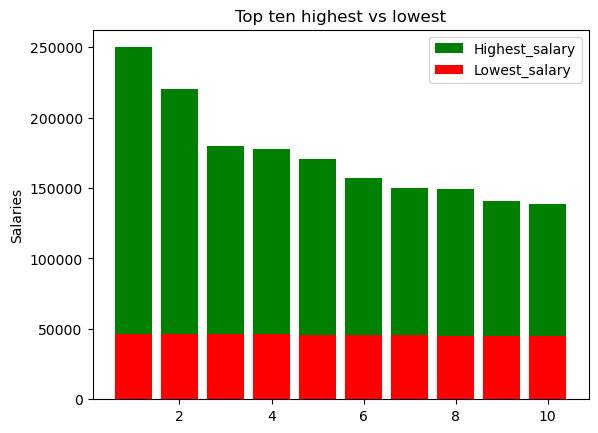

In [52]:
c= [1,2,3,4,5,6,7,8,9,10]

x=df['Salary'].sort_values(ascending=False).head(10)
y = df['Salary'].sort_values(ascending=False).tail(10)
plt.bar(c,x,color ='g',label='Highest_salary')
plt.bar(c,y,color ='r',label='Lowest_salary')
plt.title('Top ten highest vs lowest')
plt.legend()
plt.ylabel('Salaries')
plt.show()

In [53]:
df['RecruitmentSource'].unique()

array(['LinkedIn', 'Indeed', 'Google Search', 'Employee Referral',
       'Diversity Job Fair', 'On-line Web application', 'CareerBuilder',
       'Website', 'Other'], dtype=object)

In [318]:
r =df['RecruitmentSource'].value_counts()

<Axes: ylabel='count'>

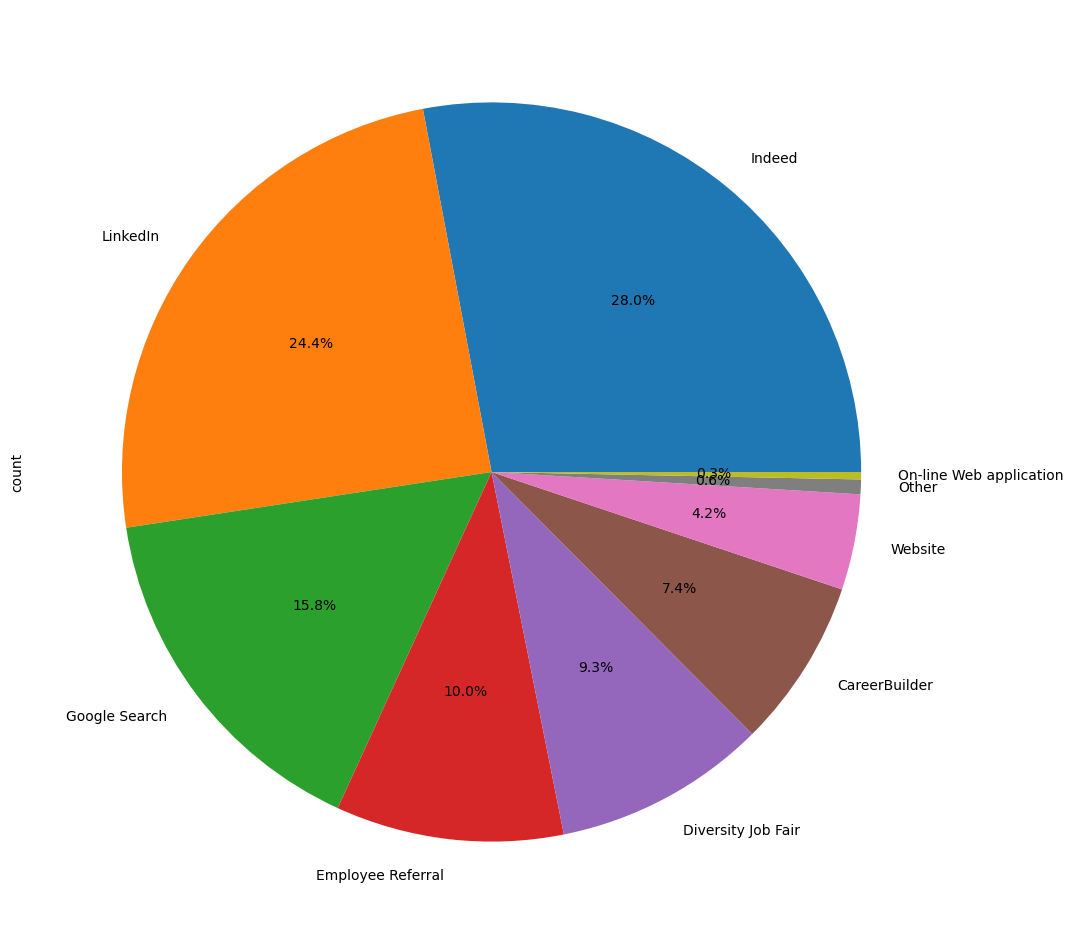

In [57]:
df['RecruitmentSource'].value_counts().plot.pie(y =df['RecruitmentSource'], figsize=(12,12), autopct='%1.1f%%')

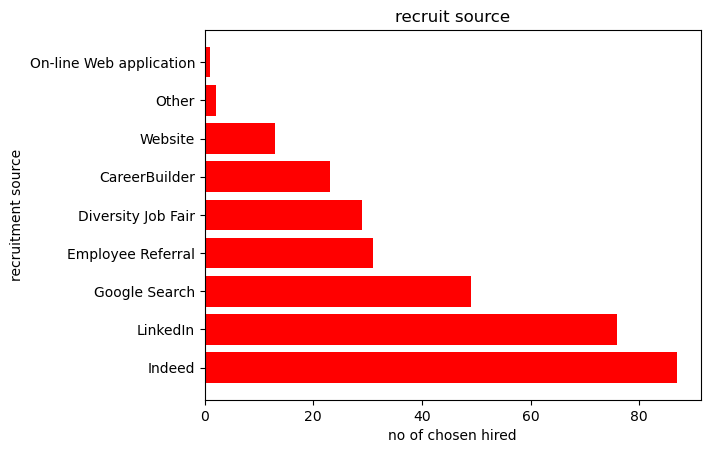

In [321]:
plt.barh(r.index, r,color ='r')
plt.title('recruit source', fontsize = 12)

plt.xlabel('no of chosen hired')
plt.ylabel('recruitment source')

plt.show()

In [62]:
z =df['PerformanceScore'].value_counts()

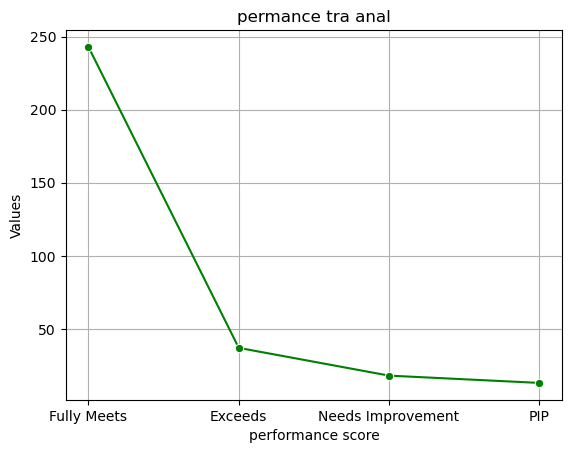

In [64]:
plt.Figure(figsize=(10,6))

sns.lineplot(data = z, marker ='o', color ='g')
plt.title('permance tra anal')
plt.xlabel('performance score')
plt.ylabel('Values')
plt.grid()
plt.show()

In [65]:
#insights generally employs meet thefully

In [68]:
e =df['EmpSatisfaction'].value_counts()

<StemContainer object of 3 artists>

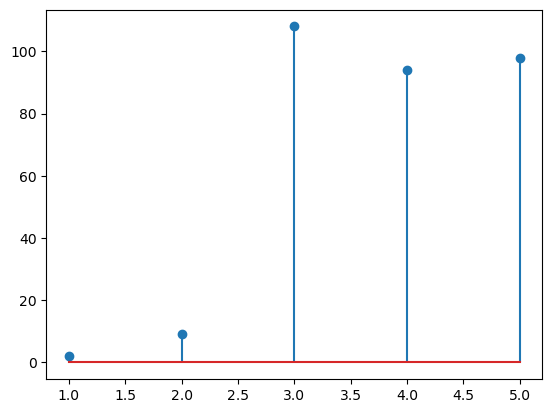

In [70]:
plt.stem(e.index,e)

In [71]:
df['EmpSatisfaction'].value_counts(normalize =True)*100

EmpSatisfaction
3    34.726688
5    31.511254
4    30.225080
2     2.893891
1     0.643087
Name: proportion, dtype: float64

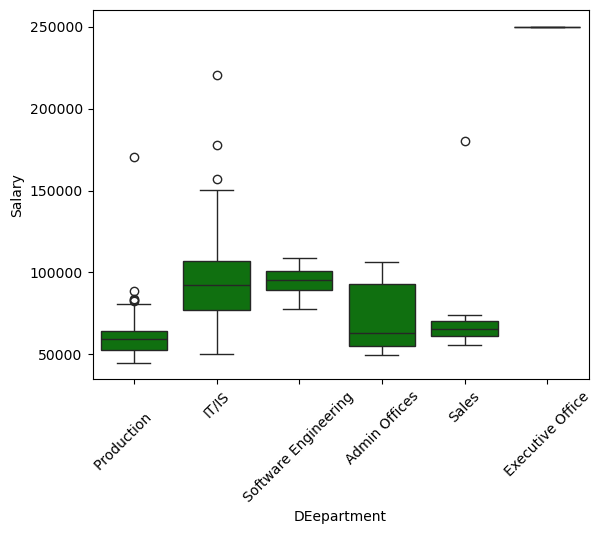

In [75]:
#outlier in salary
plt.Figure(figsize=(1,8))
sns.boxplot(x ='Department', y ='Salary',data= df, color ='g')
plt.xlabel("DEepartment")
plt.xticks(rotation =45)
plt.show()

In [76]:
#isihhts executive ae paid hiighest, least salary is production

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_18660\2517014330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x='Position', y='EngagementSurvey',palette='muted')


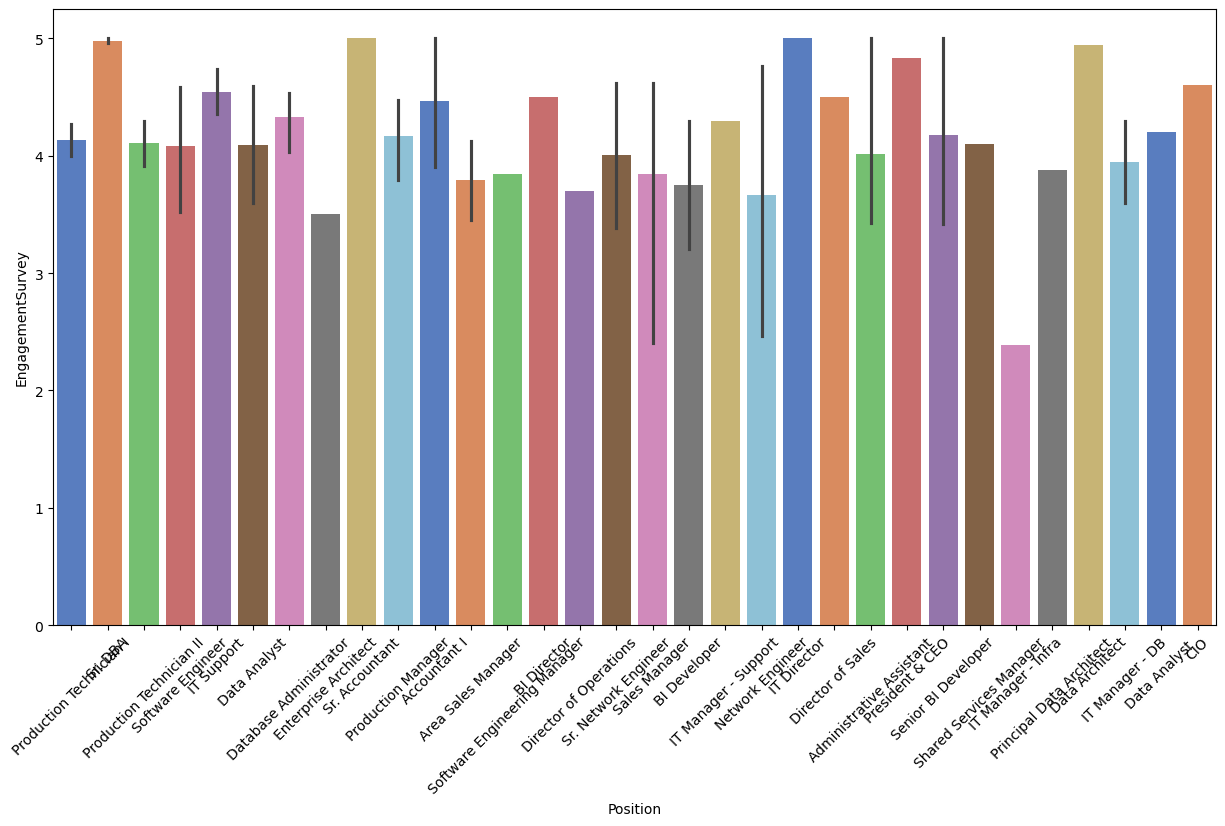

In [82]:
plt.figure(figsize=(15,8))
sns.barplot(data = df, x='Position', y='EngagementSurvey',palette='muted')
plt.xticks(rotation=45)
plt.show()

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_18660\3489086698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = a, x='Position', y='EngagementSurvey',palette='muted')


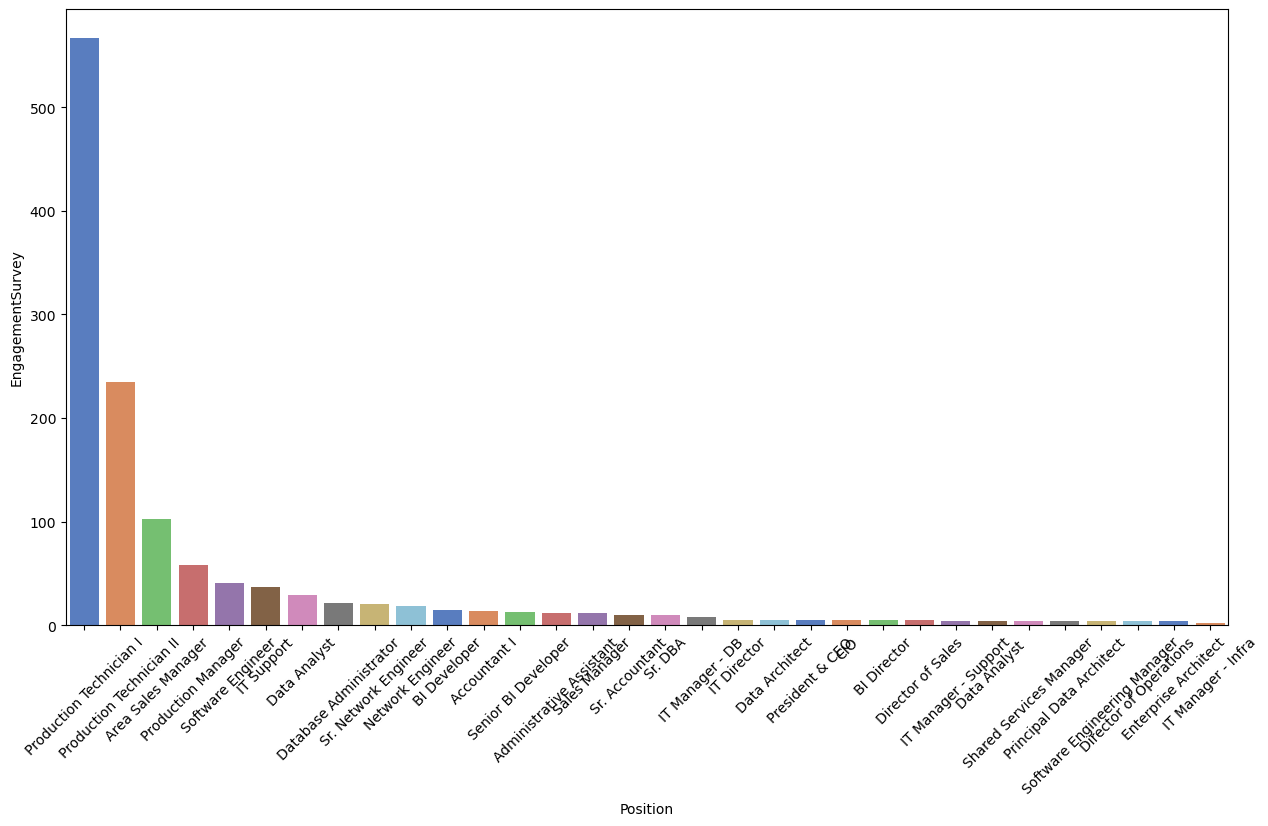

In [81]:
plt.figure(figsize=(15,8))
sns.barplot(data = a, x='Position', y='EngagementSurvey',palette='muted')
plt.xticks(rotation=45)
plt.show()

In [80]:
a =df.groupby(['Position'])['EngagementSurvey'].sum().sort_values(ascending=False).reset_index()

Text(0.5, 1.0, 'Marital status')

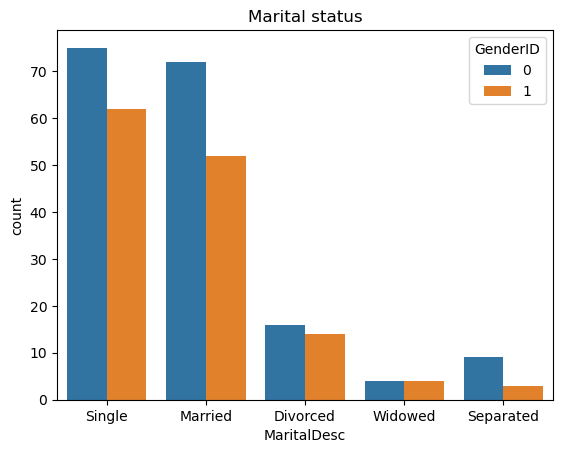

In [83]:
sns.countplot(data=df,x='MaritalDesc',hue='GenderID')
plt.title('Marital status')

In [84]:
a =df.groupby(['MaritalDesc'])['GenderID'].sum().sort_values(ascending=False).reset_index()

In [92]:
#what is the average engagment score for employes in each department
df.groupby('Department')['EngagementSurvey'].mean()

Department
Admin Offices           4.393333
Executive Office        4.830000
IT/IS                   4.154000
Production              4.129569
Sales                   3.818710
Software Engineering    4.061818
Name: EngagementSurvey, dtype: float64

In [93]:
#how many enployees have been terminated from each position

In [95]:
df[df['Termd']==1].groupby('Position')['Employee_Name'].count()

Position
Administrative Assistant     2
Area Sales Manager           4
Data Analyst                 1
Data Analyst                 1
Database Administrator       3
Enterprise Architect         1
IT Manager - DB              1
Network Engineer             1
Principal Data Architect     1
Production Manager           5
Production Technician I     52
Production Technician II    26
Sales Manager                1
Software Engineer            4
Sr. DBA                      1
Name: Employee_Name, dtype: int64

In [101]:
#what is the median salary of male and female employe
df.groupby('Sex')['Salary'].median()

Sex
F     62066.5
M     63353.0
Name: Salary, dtype: float64

In [102]:
#how many employees have been terminated for each reson

In [106]:
df[df['Termd']==1].groupby('TermReason')['Employee_Name'].count()

TermReason
Another position                    20
Fatal attraction                     1
Learned that he is a gangster        1
attendance                           7
career change                        9
gross misconduct                     1
hours                                8
maternity leave - did not return     3
medical issues                       3
military                             4
more money                          11
no-call, no-show                     4
performance                          4
relocation out of area               5
retiring                             4
return to school                     5
unhappy                             14
Name: Employee_Name, dtype: int64

In [108]:
df.groupby('TermReason')['Employee_Name'].count()

TermReason
Another position                     20
Fatal attraction                      1
Learned that he is a gangster         1
N/A-StillEmployed                   207
attendance                            7
career change                         9
gross misconduct                      1
hours                                 8
maternity leave - did not return      3
medical issues                        3
military                              4
more money                           11
no-call, no-show                      4
performance                           4
relocation out of area                5
retiring                              4
return to school                      5
unhappy                              14
Name: Employee_Name, dtype: int64

In [109]:
#what is the no. of maximum numbers of abscenes taken by employee in each department

In [113]:
df.groupby('Department')['Absences'].max()

Department
Admin Offices           20
Executive Office        10
IT/IS                   20
Production              20
Sales                   20
Software Engineering    19
Name: Absences, dtype: int64

In [114]:
#what is the total absences and average engagemengt score for each department

In [116]:
df.groupby('Department').agg({'Absences': 'sum','EngagementSurvey':'mean'})

,Absences,EngagementSurvey
Department,,
Admin Offices,78,4.393333
Executive Office,10,4.830000
IT/IS,522,4.154000
Production,2120,4.129569
Sales,358,3.818710
Software Engineering,96,4.061818


In [125]:
#what is the maximum and minimum salary days late in the last 30 day for empoyees  each position
#how many terminated employees were there in each department and what is the average employee satisfaction level among them
#what is the earliest and latest date of hire for employees in each managers team
#what is the total no. of special projects and average absences for employees in each gender category?

In [120]:
df.groupby('Sex').agg({'SpecialProjectsCount':'sum','Absences':'mean'})

,SpecialProjectsCount,Absences
Sex,,
F,183,10.261364
M,196,10.207407


In [138]:
df.groupby('Position')['DaysLateLast30'].agg(['max','min'])

,max,min
Position,,
Accountant I,0,0
Administrative Assistant,0,0
Area Sales Manager,6,0
BI Developer,0,0
BI Director,0,0
CIO,0,0
Data Analyst,0,0
Data Analyst,0,0
Data Architect,0,0


In [168]:
#how many terminated employees were there in each department and what is the average employee satisfaction level among them
df.groupby("Department").agg(
    Terminated_Count=("EmpStatusID", "count"),
    Avg_Satisfaction=("EmpSatisfaction", "mean")
).reset_index()

,Department,Terminated_Count,Avg_Satisfaction
0,Admin Offices,9,3.555556
1,Executive Office,1,3.000000
2,IT/IS,50,3.960000
3,Production,209,3.861244
4,Sales,31,4.032258
5,Software Engineering,11,4.090909


In [176]:
#what is the earliest and latest date of hire for employees in each managers team?
df["DateofHire"] = pd.to_datetime(df["DateofHire"])
df.groupby('ManagerName').agg(earliest_date=('DateofHire','min'),latest_date=('DateofHire','max'))

,earliest_date,latest_date
ManagerName,,
Alex Sweetwater,2011-05-02,2014-11-10
Amy Dunn,2011-01-10,2015-05-11
Board of Directors,2009-01-05,2012-07-02
Brandon R. LeBlanc,2008-10-27,2015-05-01
Brannon Miller,2008-09-02,2018-07-09
Brian Champaigne,2016-10-02,2017-04-20
David Stanley,2007-11-05,2015-03-30
Debra Houlihan,2011-11-07,2014-05-18
Elijiah Gray,2008-01-07,2016-06-06


In [388]:
df['DOB'] = pd.to_datetime(df['DOB'])
df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['DateofTermination']= pd.to_datetime(df['DateofTermination'])
df['LastPerformanceReview_Date'] = pd.to_datetime(df['LastPerformanceReview_Date'])


C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_19704\4097949624.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DOB'] = pd.to_datetime(df['DOB'])


In [323]:
df.dtypes

Employee_Name                         object
EmpID                                  int64
MarriedID                              int64
MaritalStatusID                        int64
GenderID                               int64
EmpStatusID                            int64
DeptID                                 int64
PerfScoreID                            int64
FromDiversityJobFairID                 int64
Salary                                 int64
Termd                                  int64
PositionID                             int64
Position                              object
State                                 object
Zip                                    int64
DOB                           datetime64[ns]
Sex                                   object
MaritalDesc                           object
CitizenDesc                           object
HispanicLatino                        object
RaceDesc                              object
DateofHire                    datetime64[ns]
DateofTerm

In [389]:
df['ManagerID'].isnull().sum()

np.int64(8)

In [390]:
df['ManagerID'].mode()[0]

np.float64(12.0)

In [391]:
df['ManagerID'].fillna(df['ManagerID'].mode()[0],inplace=True)

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_19704\802242088.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ManagerID'].fillna(df['ManagerID'].mode()[0],inplace=True)


In [392]:
df['dob_year'] = df['DOB'].dt.year
df['dob_month'] = df['DOB'].dt.month
df['dob_day']= df['DOB'].dt.day
df['hire_year'] = df['DateofHire'].dt.year
df['hire_month'] = df['DateofHire'].dt.month
df['hire_day']= df['DateofHire'].dt.day
df['perf_year'] = df['LastPerformanceReview_Date'].dt.year
df['perf_month'] = df['LastPerformanceReview_Date'].dt.month
df['perf_day'] = df['LastPerformanceReview_Date'].dt.day

In [393]:
df.drop('DateofTermination', axis=1,inplace=True)

In [394]:
df.drop('DOB',axis=1,inplace=True)

In [395]:
df.drop('DateofHire',axis=1,inplace=True)
df.drop('LastPerformanceReview_Date',axis=1,inplace=True)

In [396]:
df['HispanicLatino'] =df['HispanicLatino'].replace('yes','Yes')
df['HispanicLatino'] =df['HispanicLatino'].replace('no','No')

In [397]:
df.drop('Employee_Name',axis=1, inplace=True)
df.drop('EmpID',axis=1,inplace=True)

In [398]:
df.columns

Index(['MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID',
       'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd',
       'PositionID', 'Position', 'State', 'Zip', 'Sex', 'MaritalDesc',
       'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'TermReason',
       'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID',
       'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey',
       'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences',
       'dob_year', 'dob_month', 'dob_day', 'hire_year', 'hire_month',
       'hire_day', 'perf_year', 'perf_month', 'perf_day'],
      dtype='object')

In [412]:
df['RecruitmentSource'].unique()

array(['LinkedIn', 'Indeed', 'Google Search', 'Employee Referral',
       'Diversity Job Fair', 'On-line Web application', 'CareerBuilder',
       'Website', 'Other'], dtype=object)

In [400]:
df.dtypes

MarriedID                   int64
MaritalStatusID             int64
GenderID                    int64
EmpStatusID                 int64
DeptID                      int64
PerfScoreID                 int64
FromDiversityJobFairID      int64
Salary                      int64
Termd                       int64
PositionID                  int64
Position                   object
State                      object
Zip                         int64
Sex                        object
MaritalDesc                object
CitizenDesc                object
HispanicLatino             object
RaceDesc                   object
TermReason                 object
EmploymentStatus           object
Department                 object
ManagerName                object
ManagerID                 float64
RecruitmentSource          object
PerformanceScore           object
EngagementSurvey          float64
EmpSatisfaction             int64
SpecialProjectsCount        int64
DaysLateLast30              int64
Absences      

In [519]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [352]:
from sklearn.preprocessing import LabelEncoder
categorical_variables = {}

#Creating categories denoted by integers from column values
for col in df.columns:
    cat_var_name = "cat_"+ col
    cat_var_name = LabelEncoder()
    cat_var_name.fit(df[col])
    df[col] = cat_var_name.transform(df[col])
    categorical_variables[col] = cat_var_name

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   MarriedID               311 non-null    int64
 1   MaritalStatusID         311 non-null    int64
 2   GenderID                311 non-null    int64
 3   EmpStatusID             311 non-null    int64
 4   DeptID                  311 non-null    int64
 5   PerfScoreID             311 non-null    int64
 6   FromDiversityJobFairID  311 non-null    int64
 7   Salary                  311 non-null    int64
 8   Termd                   311 non-null    int64
 9   PositionID              311 non-null    int64
 10  Position                311 non-null    int64
 11  State                   311 non-null    int64
 12  Zip                     311 non-null    int64
 13  Sex                     311 non-null    int64
 14  MaritalDesc             311 non-null    int64
 15  CitizenDesc            

In [511]:
df['EmpSatisfaction'].unique()

array([5, 3, 4, 2, 1])

In [514]:
x = x.drop('EngagementSurvey', axis=1)

In [513]:
x

,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,PositionID,State,MaritalDesc,CitizenDesc,...,EmploymentStatus,RecruitmentSource,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,dob_year,hire_year,perf_year
0,0,1,1,5,4,0,19,MA,Single,US Citizen,...,Active,LinkedIn,4.60,5,0,0,1,1983,2011,2019
1,1,1,5,3,3,0,27,MA,Married,US Citizen,...,Voluntarily Terminated,Indeed,4.96,3,6,0,17,2075,2015,2016
2,1,0,5,5,3,0,20,MA,Married,US Citizen,...,Voluntarily Terminated,LinkedIn,3.02,3,0,0,3,1988,2011,2012
3,1,0,1,5,3,0,19,MA,Married,US Citizen,...,Active,Indeed,4.84,5,0,0,15,1988,2008,2019
4,2,0,5,5,3,0,19,MA,Divorced,US Citizen,...,Voluntarily Terminated,Google Search,5.00,4,0,0,2,1989,2011,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,0,1,1,5,3,0,20,MA,Single,US Citizen,...,Active,LinkedIn,4.07,4,0,0,13,1985,2014,2019
307,0,0,5,5,1,0,19,MA,Single,US Citizen,...,Voluntarily Terminated,Google Search,3.20,2,0,5,4,1982,2008,2015
308,0,0,1,3,4,0,6,MA,Single,US Citizen,...,Active,Employee Referral,4.60,5,6,0,16,1979,2010,2019
309,0,0,1,3,3,0,9,MA,Single,US Citizen,...,Active,Employee Referral,5.00,3,5,0,11,1979,2015,2019


In [515]:
vif = pd.DataFrame()
vif['features'] = x.columns

In [516]:
vif

,features
0,MaritalStatusID
1,GenderID
2,EmpStatusID
3,DeptID
4,PerfScoreID
5,FromDiversityJobFairID
6,PositionID
7,State
8,MaritalDesc
9,CitizenDesc


In [521]:
df['RecruitmentSource'].unique()

array(['LinkedIn', 'Indeed', 'Google Search', 'Employee Referral',
       'Diversity Job Fair', 'On-line Web application', 'CareerBuilder',
       'Website', 'Other'], dtype=object)

In [363]:
df.drop('Position',axis=1,inplace=True)

In [522]:
df['Salary'].unique()

array([ 62506, 104437,  64955,  64991,  50825,  57568,  95660,  59365,
        47837,  50178,  54670,  47211,  92328,  58709,  52505,  57834,
        70131,  59026, 110000,  53250,  51044,  64919,  62910,  66441,
        57815, 103613, 106367,  74312,  53492,  63000,  65288,  64375,
        74326,  63763,  62162,  77692,  72640,  93396,  52846, 100031,
        71860,  61656, 110929,  54237,  60380,  66808,  64786,  64816,
        68678,  64066,  59369,  50373,  63108,  59144,  68051, 170500,
        63381,  83552,  56149,  92329,  65729,  85028,  57583,  56294,
        56991,  55722, 101199,  61568,  58275,  53189,  96820,  51259,
        59231,  61584,  46335,  70621, 138888,  74241,  75188,  62514,
        60070,  48888,  54285,  56847,  60340,  59124,  99280,  71776,
        65902,  57748,  64057,  53366,  58530,  72609,  55965,  70187,
       178000,  99351,  67251,  65707,  52249,  53171,  51337,  51505,
        59370,  54933,  61555, 114800,  74679,  53018,  59892,  68898,
      

In [525]:
x = x.drop('RecruitmentSource',axis=1)

In [523]:
from sklearn.model_selection import train_test_split

In [373]:
x = df.drop('RecruitmentSource',axis=1)

In [531]:
y=df['RecruitmentSource']

In [545]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2 , random_state=1)

In [533]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((248, 21), (63, 21), (248,), (63,))

In [537]:
#encoding of data 
cat_features = x.select_dtypes(include='object').columns
num_features = x.select_dtypes(exclude='object').columns

In [538]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [539]:
numerial_trans = StandardScaler()
Oh_trans = OneHotEncoder()# n features then >> n-1 dummy feature 

preprocesso =ColumnTransformer(
    [
        ("OneHotEncoder", Oh_trans,cat_features),
        ("StandardScaler", numerial_trans,num_features)
    ]
)

In [540]:
preprocesso

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(),
                                 Index(['State', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'TermReason', 'EmploymentStatus'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID',
       'FromDiversityJobFairID', 'PositionID', 'EmpSatisfaction',
       'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'dob_year',
       'hire_year', 'perf_year'],
      dtype='object'))])

In [546]:
x_train = preprocesso.fit_transform(x_train)

In [549]:
x_train_array = x_train.toarray()

In [553]:
# After fitting
feature_names = preprocesso.get_feature_names_out()
x_train_df = pd.DataFrame(x_train.toarray(), columns=feature_names)

In [554]:
x_train_df

,OneHotEncoder__State_AL,OneHotEncoder__State_AZ,OneHotEncoder__State_CA,OneHotEncoder__State_CO,OneHotEncoder__State_CT,OneHotEncoder__State_FL,OneHotEncoder__State_GA,OneHotEncoder__State_ID,OneHotEncoder__State_IN,OneHotEncoder__State_KY,...,StandardScaler__PerfScoreID,StandardScaler__FromDiversityJobFairID,StandardScaler__PositionID,StandardScaler__EmpSatisfaction,StandardScaler__SpecialProjectsCount,StandardScaler__DaysLateLast30,StandardScaler__Absences,StandardScaler__dob_year,StandardScaler__hire_year,StandardScaler__perf_year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.740706,-0.296174,0.370222,1.147447,-0.525159,-0.316792,-1.518447,-0.688667,-0.849993,0.593721
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.041119,-0.296174,0.525054,-0.992154,-0.525159,-0.316792,0.695697,-0.460880,-0.849993,0.593721
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.041119,-0.296174,0.370222,1.147447,-0.525159,-0.316792,-0.496534,-0.460880,0.178291,0.593721
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.041119,-0.296174,0.370222,-0.992154,-0.525159,-0.316792,-1.518447,-0.815215,-0.335851,0.593721
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.041119,-0.296174,-1.952250,1.147447,1.582274,-0.316792,-0.326215,-0.536809,2.234861,0.593721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.041119,-0.296174,0.370222,1.147447,-0.525159,-0.316792,-1.007491,-0.663357,0.178291,0.593721
244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.041119,-0.296174,-2.261913,-0.992154,1.582274,-0.316792,-1.348128,-0.562118,1.206576,0.593721
245,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.358055,-0.296174,-2.107082,-3.131755,-0.525159,1.238939,1.206654,-0.587428,-0.335851,0.593721
246,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.041119,-0.296174,0.370222,-0.992154,-0.525159,-0.316792,0.184741,1.614509,-0.849993,-1.133467


In [555]:
x_test = preprocesso.fit_transform(x_test)

In [557]:
x_test = pd.DataFrame(x_test)

In [558]:
x_test

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.027503,-0.408248,0.441942,0.327281,-0.497519,-0.337032,-0.811992,-0.640385,0.593121,0.704086
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.027503,-0.408248,0.839689,-0.961388,2.189082,-0.337032,0.989258,1.415214,2.107984,0.704086
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.760209,-0.408248,-2.342291,1.615951,2.189082,-0.337032,0.809133,-0.838515,-1.426696,0.704086
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.027503,-0.408248,0.243068,0.327281,-0.497519,-0.337032,-0.271617,-0.912813,1.098075,0.704086
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-1.705203,-0.408248,0.243068,-0.961388,-0.497519,3.454573,1.349508,-0.590852,0.593121,-0.148941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.027503,-0.408248,-0.751301,1.615951,2.189082,-0.337032,0.809133,-0.615618,1.098075,0.704086
59,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.027503,-0.408248,-2.938913,1.615951,-0.497519,2.696252,-0.811992,1.539046,0.593121,0.704086
60,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.760209,-0.408248,0.441942,-0.961388,-0.497519,-0.337032,0.809133,1.316149,1.603029,0.704086
61,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.027503,-0.408248,-1.347922,0.327281,-0.497519,-0.337032,1.349508,1.316149,0.593121,0.704086


In [560]:
encoder = OneHotEncoder()

In [562]:
y_train = pd.DataFrame(y_train)
y_train = encoder.fit_transform(y_train)

In [564]:
y_train = y_train.toarray()

In [566]:
y_train = pd.DataFrame(y_train)

In [567]:
y_train

,0,1,2,3,4,5,6,7,8
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
243,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
245,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
246,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [568]:
model.fit(x_train_df,y_train)

LinearRegression()

In [569]:
model.coef_

array([[-2.36102261e-01, -2.16280600e-01, -1.92733637e-01,
        -1.72015602e-02,  1.63478095e-01, -1.17549258e-01,
        -8.34229915e-02,  9.55325137e-01, -8.49945891e-02,
        -2.21277460e-01,  4.61613469e-02, -4.26763378e-02,
        -2.97430556e-01,  1.73050366e-02, -1.69928804e-01,
         3.20796172e-02, -1.48539415e-01,  6.87784609e-02,
         1.18534734e+00, -1.96878834e-01,  7.18482325e-02,
        -7.06362111e-03, -8.47066868e-02, -1.25948010e-01,
        -6.07308930e-02, -2.36857750e-01, -5.24685093e-03,
         3.31005793e-02, -1.89800062e-02, -1.38334020e-02,
         4.95967979e-03, -8.19125536e-03, -3.88105665e-02,
         4.70018219e-02,  5.22673505e-03, -5.22673505e-03,
        -4.87442202e-02, -6.57713270e-03,  6.25057071e-02,
        -1.00768363e-02,  2.89248210e-03, -1.62593789e-01,
        -2.03544646e-02, -7.35422901e-02, -1.66889949e-01,
         3.10284903e-02, -8.76955877e-02,  3.67853384e-02,
         2.84978207e-01,  2.55404773e-01, -7.10525715e-0

In [570]:
model.intercept_

array([ 0.04726884,  0.08064516, -0.07001837,  0.13785771,  0.35988985,
        0.14815333,  0.02044646,  0.0605343 ,  0.21522273])

In [73]:
# 1. Transform your data
x_train_transformed = preprocesso.fit_transform(x_train)

# 2. Convert sparse matrix to dense array
x_train_array = x_train_transformed.toarray()

# 3. Get feature names from the transformer
feature_names = preprocesso.get_feature_names_out()

# 4. Wrap into a DataFrame
x_train_df = pd.DataFrame(x_train_array, columns=feature_names)

In [571]:
y_pred = model.predict(x_test)

c:\Users\TAHERALI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: X has 49 features, but LinearRegression is expecting 75 features as input.

In [385]:
mean_squared_error(y_test,y_pred)

2.7347575243608824

In [386]:
r2_score(y_test,y_pred)

0.03431916243875954

In [301]:
encoder = OneHotEncoder(handle_unknown='ignore')
y_train_enc = encoder.fit_transform(y_train_df)
y_test_enc  = encoder.transform(y_test_df)

In [302]:
x_test_df = x_test_df.reindex(columns=x_train_df.columns, fill_value=0)
y_test_df = y_test_df.reindex(columns=y_train_df.columns, fill_value=0)

In [303]:
baseline_pred = np.tile(y_test_df.mean().values, (len(y_test_df), 1))
print(r2_score(y_test_df, baseline_pred))

0.0


In [264]:
x_train = encoder.fit_transform(x_train)

In [265]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 248 stored elements and shape (248, 4)>

In [266]:
x_train_array = x_train.toarray()

In [267]:
x_train_df =pd.DataFrame(x_train_array)

In [268]:
x_train_df

,0,1,2,3
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
243,0.0,1.0,0.0,0.0
244,0.0,1.0,0.0,0.0
245,0.0,0.0,0.0,1.0
246,0.0,1.0,0.0,0.0


In [269]:
x_test = pd.DataFrame(x_test)

In [270]:
x_test = encoder.fit_transform(x_test)

In [271]:
x_test_array = x_test.toarray()

In [272]:
x_test_df = pd.DataFrame(x_test_array)

In [273]:
x_test_df

,0,1,2,3
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
58,0.0,1.0,0.0,0.0
59,0.0,0.0,0.0,1.0
60,1.0,0.0,0.0,0.0
61,0.0,1.0,0.0,0.0


In [151]:
encoder = OneHotEncoder()

In [275]:
y_train_df = pd.DataFrame(y_train)

In [276]:
y_train_df

,EmpSatisfaction
0,5
189,3
110,5
62,3
120,5
...,...
203,5
255,3
72,1
235,3


In [277]:
y_test_df = pd.DataFrame(y_test)

In [156]:
feature = encoder.get_feature_names_out()

In [178]:
y_test_array = y_test.toarray()

In [179]:
y_test_df = pd.DataFrame(y_test_array)

In [278]:
y_test_df

,EmpSatisfaction
88,4
197,3
308,5
186,4
85,3
...,...
9,5
95,5
16,3
131,4


In [113]:
category = OneHotEncoder()

In [162]:
y_train = encoder.fit_transform(y_train)

In [161]:
y_train = pd.DataFrame(y_train)

In [127]:
y_train_array

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [163]:
y_train_array = y_train.toarray()

In [164]:
y_train_df = pd.DataFrame(y_train_array)

In [94]:
from sklearn.linear_model import LinearRegression

In [232]:
model = LinearRegression()

In [233]:
model

LinearRegression()

In [304]:
model.fit(x_train_df,y_train_df)

LinearRegression()

In [305]:
model.coef_

array([[ 0.65945569,  0.62110242,  0.12895171, -1.40950983]])

In [306]:
model.intercept_

array([3.40950983])

In [307]:
x_train_df.shape,y_train_df.shape

((248, 4), (248, 1))

In [283]:
y_test_df

,EmpSatisfaction
88,4
197,3
308,5
186,4
85,3
...,...
9,5
95,5
16,3
131,4


In [308]:
y_pred = model.predict(x_test_df)

In [309]:
y_pred

array([[4.03061224],
       [4.03061224],
       [4.06896552],
       [4.03061224],
       [3.53846154],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.06896552],
       [3.53846154],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [3.53846154],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.06896552],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.06896552],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.06896552],
       [4.03061224],
       [4.03061224],
       [4.06896552],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.03061224],
       [4.030

In [167]:
x_test_df = x_test_df.reindex(columns=x_train_df.columns, fill_value=0)

In [170]:
from sklearn.metrics import mean_squared_error,r2_score

In [310]:
mean_squared_error(y_test_df,y_pred)

0.9373061058809378

In [314]:
r2_score(y_test_df,y_pred)

-0.5565556210215239

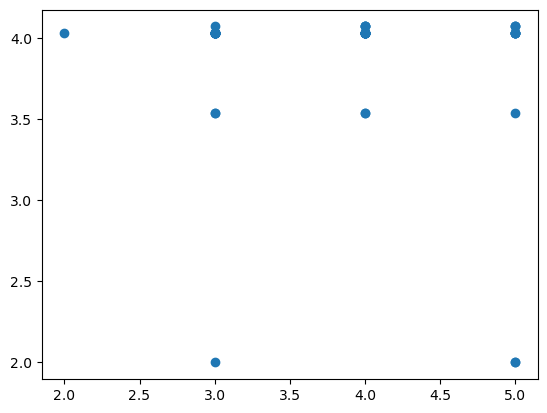

In [294]:
plt.scatter(y_test_df,y_pred)

In [292]:
error = y_test_df-y_pred

In [293]:
error

,EmpSatisfaction
88,-0.030612
197,-1.030612
308,0.931034
186,-0.030612
85,-0.538462
...,...
9,0.969388
95,3.000000
16,-1.068966
131,-0.030612


<Axes: ylabel='Count'>

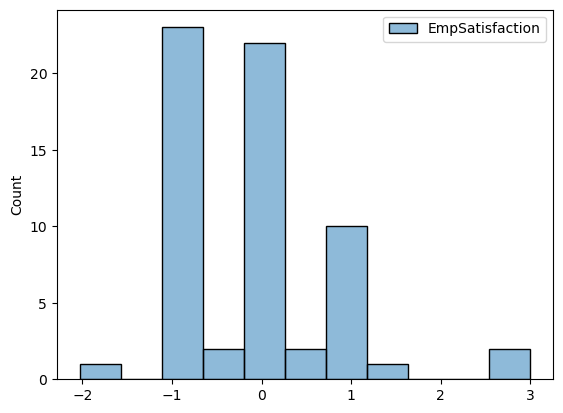

In [295]:
sns.histplot(error)

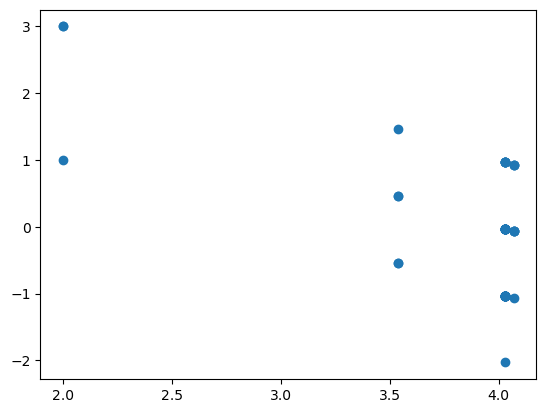

In [296]:
plt.scatter(y_pred,error)